In [1]:
import pandas as pd 
import numpy as np
from sklearn import linear_model
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv(r"C:\Users\madso\DS_AI_Internship\src\day26\homeprices.csv")
df.head()

,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


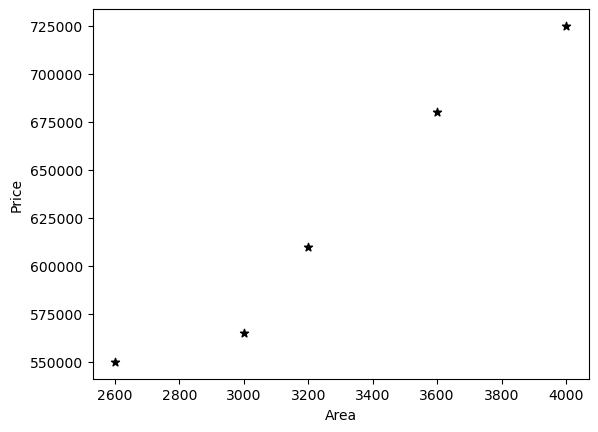

In [3]:
plt.xlabel('Area')
plt.ylabel('Price')
plt.scatter(df.area,df.price,color='black',marker='*')

In [4]:
area = df.drop('price',axis = 'columns')
area

,area
0,2600
1,3000
2,3200
3,3600
4,4000


In [5]:
price = df.price
price

0    550000
1    565000
2    610000
3    680000
4    725000
Name: price, dtype: int64

In [6]:
reg = linear_model.LinearRegression()
reg.fit(area,price)

LinearRegression()

In [7]:
reg.coef_

array([135.78767123])

In [8]:
reg.intercept_

180616.43835616432

In [9]:
reg.predict([[3500]])

C:\Users\madso\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([655873.28767123])

In [20]:
new_data=pd.DataFrame([[3500]],columns=['area'])
prediction=reg.predict(new_data)
prediction=np.round(prediction,2)
prediction

array([655873.29])

In [28]:
p = reg.predict(df[['area']])
p = np.round(p,2)
p

array([533664.38, 587979.45, 615136.99, 669452.05, 723767.12])

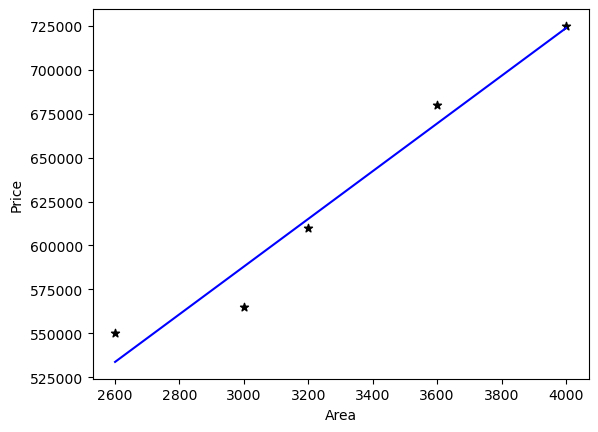

In [32]:
plt.xlabel('Area')
plt.ylabel('Price')
plt.scatter(df.area,df.price,color='black',marker='*')
plt.plot(df.area,reg.predict(df[['area']]),color= 'blue')

In [34]:
reg.score(df[['area']],df.price)

0.9584301138199486

In [40]:
new_data=pd.DataFrame([[6500]],columns=['area'])
prediction=reg.predict(new_data)
prediction=np.round(prediction,2)
prediction

array([1063236.3])

In [42]:
new_data=pd.DataFrame([[10000]],columns=['area'])
prediction=reg.predict(new_data)
prediction=np.round(prediction,2)
prediction

array([1538493.15])

In [50]:
d = pd.read_csv(r"C:\Users\madso\DS_AI_Internship\src\day26\areas.csv")
d.head()

,area
0,1000
1,1500
2,2300
3,3540
4,4120


In [52]:
pred = reg.predict(d)
pred = np.round(pred,2)
pred

array([ 316404.11,  384297.95,  492928.08,  661304.79,  740061.64,
        799808.22,  926090.75,  650441.78,  825607.88,  492928.08,
       1402705.48, 1348390.41, 1144708.9 ])

In [64]:
d['predicted_price'] = pred
d

,area,predicted_price
0,1000,316404.11
1,1500,384297.95
2,2300,492928.08
3,3540,661304.79
4,4120,740061.64
5,4560,799808.22
6,5490,926090.75
7,3460,650441.78
8,4750,825607.88
9,2300,492928.08


In [68]:
d.to_csv(r"C:\Users\madso\DS_AI_Internship\src\day26\price.csv", index=False)

In [72]:
reg.score(d[['area']],d.predicted_price)

0.9999999999999999